Circumstances causing me to use CSV are explained elsewhere.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:
# remove duplicates
df = df.drop_duplicates()

# handle missing values
df = df.dropna()

# drop ID columns if they exist
df = df.drop(columns=["LoanID"], errors="ignore")

df.shape

(255347, 17)

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
df.columns.to_list()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

Builing Model - Random Forest Classifier.

In [9]:
X = df.drop(columns=["Default"])
y = df["Default"]

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,        # more trees → better stability
    max_depth=12,            # prevents overfitting
    min_samples_split=10,    # regularization
    min_samples_leaf=5,      # smoother decision boundaries
    max_features="sqrt",     # standard best practice
    class_weight="balanced_subsample", # important for Default imbalance
    random_state=42,
    n_jobs=-1
)

In [25]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.771999216761308
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.56      0.36      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070



Evaluating Model Performance + Comparing to a Threshold for Aggressive Risk Targeting.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# --- Predictions ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# --- Standard evaluation ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- ROC-AUC (important for imbalanced classification) ---
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

# --- Optional: threshold tuning for better recall on defaults ---
threshold = 0.35  # lower than 0.5 to catch more defaulters
y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n--- Adjusted Threshold Results ---")
print(classification_report(y_test, y_pred_adjusted))

Accuracy: 0.771999216761308

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.56      0.36      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070

ROC-AUC: 0.7542511682445855

--- Adjusted Threshold Results ---
              precision    recall  f1-score   support

           0       0.96      0.49      0.65     45139
           1       0.18      0.84      0.29      5931

    accuracy                           0.53     51070
   macro avg       0.57      0.66      0.47     51070
weighted avg       0.87      0.53      0.61     51070



Creating Visualizations.

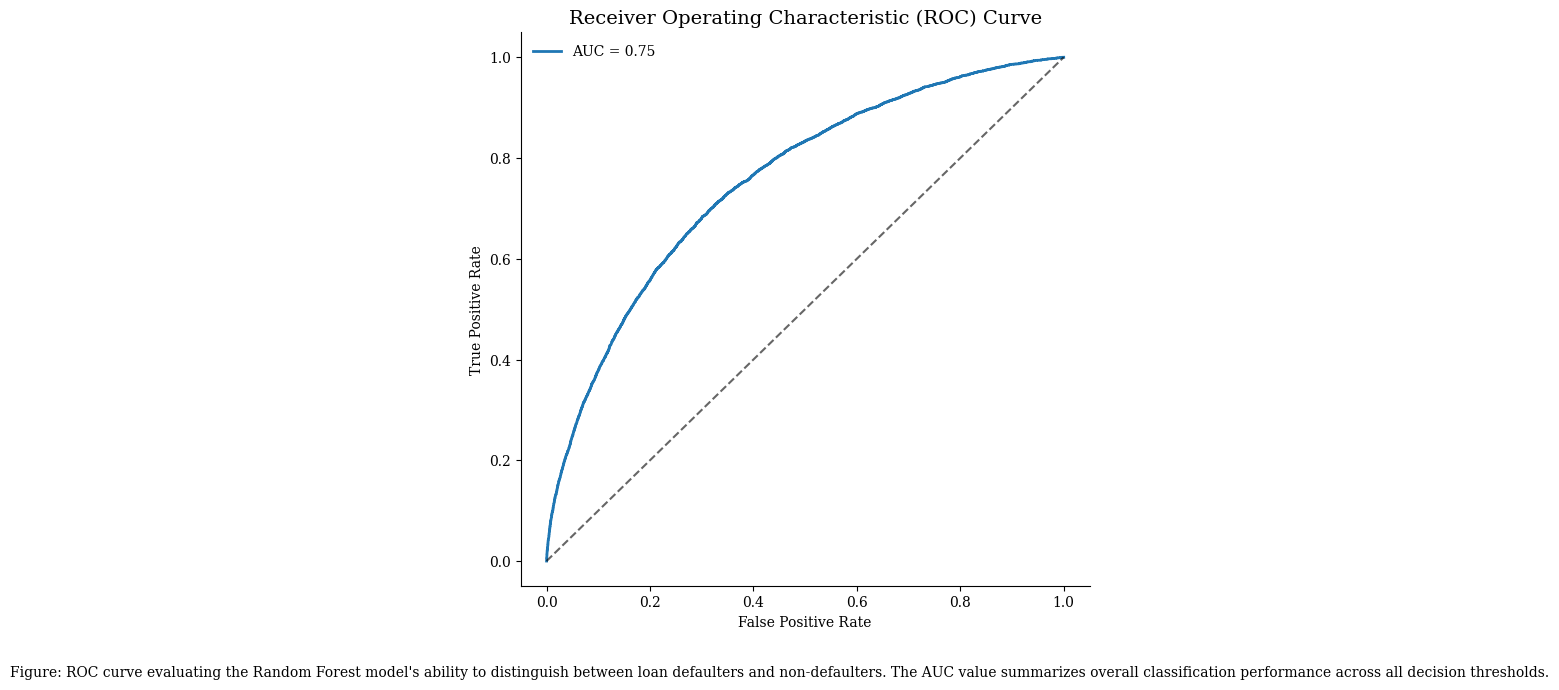

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["DejaVu Serif"]

# probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# ROC computation
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6.5, 6.5))

# ROC curve
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.2f}")

# diagonal baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="black", alpha=0.6)

plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(frameon=False)

# clean styling
plt.grid(False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# caption (publication style)
plt.figtext(
    0.5, -0.05,
    "Figure: ROC curve evaluating the Random Forest model's ability to distinguish between loan defaulters and non-defaulters. "
    "The AUC value summarizes overall classification performance across all decision thresholds.",
    ha="center",
    fontsize=10
)

plt.show()

In [40]:
features

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes',
       'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',
       'LoanPurpose_Other', 'HasCoSigner_Yes'],
      dtype='object')

In [57]:
feature_name_map = {
    "Age": "Age",
    "Income": "Income",
    "LoanAmount": "Loan Amount",
    "CreditScore": "Credit Score",
    "MonthsEmployed": "Months Employed",
    "NumCreditLines": "Number of Credit Lines",
    "InterestRate": "Interest Rate",
    "LoanTerm": "Loan Term",
    "DTIRatio": "DTI Ratio",

    "Education_High School": "High School Education",
    "Education_Bachelor's": "Bachelor's Degree",
    "Education_Master's": "Master's Degree",
    "Education_PhD": "PhD",

    "EmploymentType_Part-time": "Part-time Employment",
    "EmploymentType_Self-employed": "Self Employed",
    "EmploymentType_Unemployed": "Unemployed",

    "MaritalStatus_Married": "Married",
    "MaritalStatus_Single": "Single",

    "HasMortgage_Yes": "Has Mortgage",
    "HasDependents_Yes": "Has Dependents",
    "HasCoSigner_Yes": "Has Co-Signer",

    "LoanPurpose_Business": "Business Loan",
    "LoanPurpose_Education": "Education Loan",
    "LoanPurpose_Home": "Home Loan",
    "LoanPurpose_Other": "Other Loan Purpose"
}

In [58]:
importances = model.feature_importances_
features = X.columns

clean_features = [feature_name_map.get(f, f) for f in features]

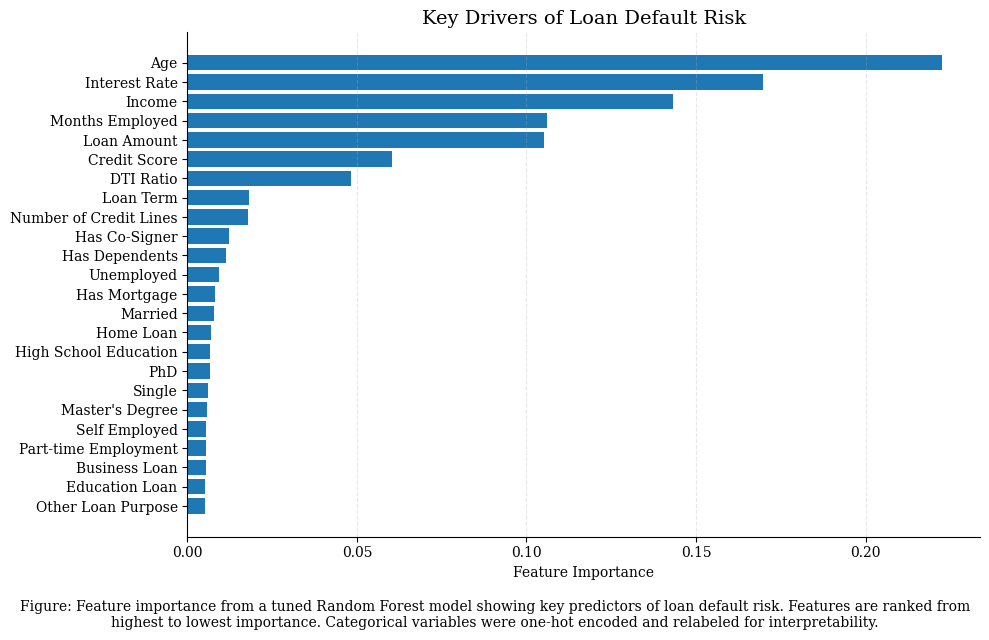

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = ["DejaVu Serif"]

# --- sort by importance (NOT feature names) ---
indices = np.argsort(importances)  # descending order

plt.figure(figsize=(10, 6))

plt.barh(
    [clean_features[i] for i in indices],
    importances[indices]
)

plt.title("Key Drivers of Loan Default Risk", fontsize=14)

plt.xlabel("Feature Importance")
plt.ylabel("")

# optional: keep clean but readable
plt.grid(axis="x", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.figtext(
    0.5, -0.05,
    "Figure: Feature importance from a tuned Random Forest model showing key predictors of loan default risk. "
    "Features are ranked from highest to lowest importance. Categorical variables were one-hot encoded and relabeled for interpretability.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10
)

plt.show()

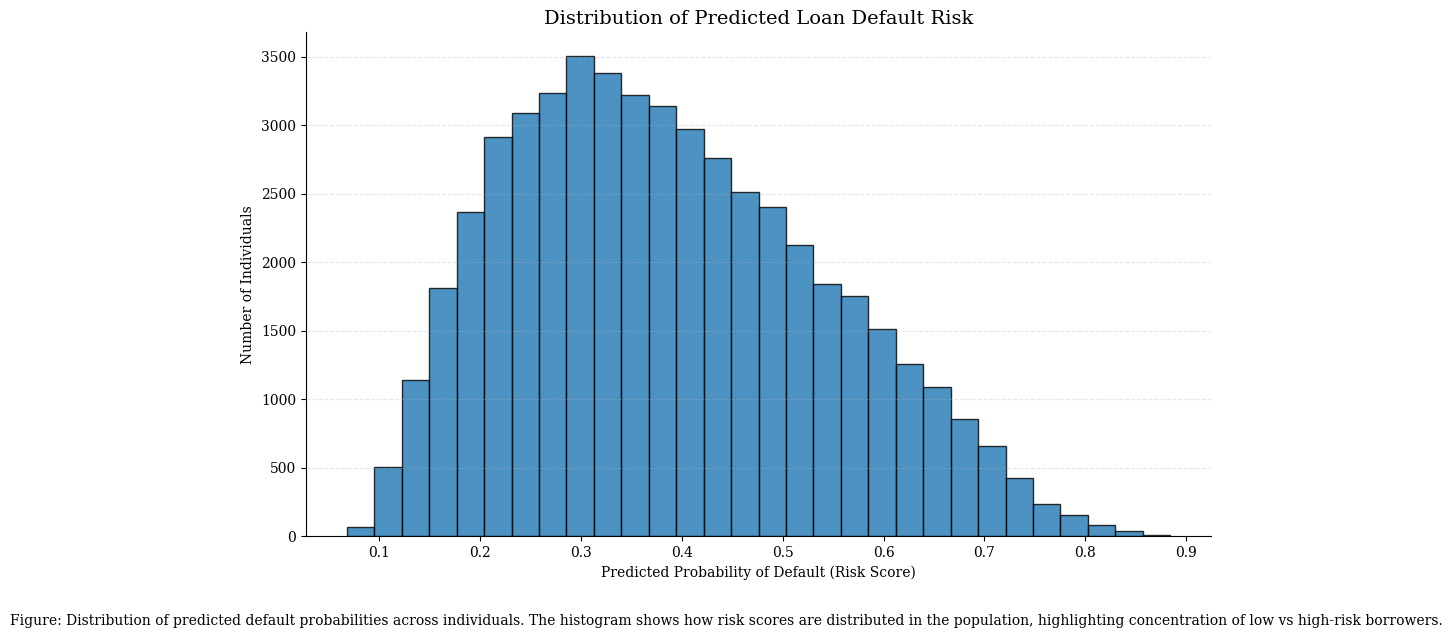

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["DejaVu Serif"]

# predicted probabilities
risk_scores = model.predict_proba(X_test)[:, 1]

# --- plot distribution ---
plt.figure(figsize=(10, 6))

plt.hist(
    risk_scores,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Predicted Loan Default Risk", fontsize=14)

# correct axes (THIS is what you wanted)
plt.xlabel("Predicted Probability of Default (Risk Score)")
plt.ylabel("Number of Individuals")

plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# caption
plt.figtext(
    0.5, -0.05,
    "Figure: Distribution of predicted default probabilities across individuals. "
    "The histogram shows how risk scores are distributed in the population, "
    "highlighting concentration of low vs high-risk borrowers.",
    ha="center",
    fontsize=10
)

plt.show()

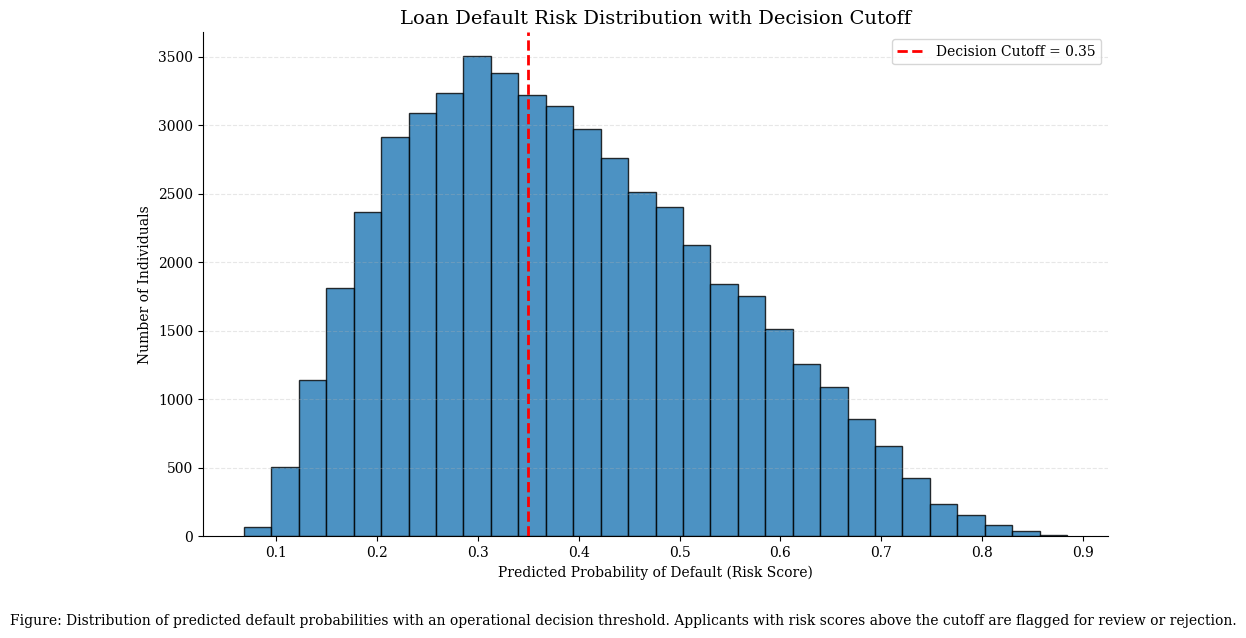

In [55]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["DejaVu Serif"]

# predicted probabilities
risk_scores = model.predict_proba(X_test)[:, 1]

cutoff = 0.35  # chosen business threshold

plt.figure(figsize=(10, 6))

plt.hist(
    risk_scores,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# vertical cutoff line
plt.axvline(
    cutoff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Decision Cutoff = {cutoff}"
)

plt.title("Loan Default Risk Distribution with Decision Cutoff", fontsize=14)

plt.xlabel("Predicted Probability of Default (Risk Score)")
plt.ylabel("Number of Individuals")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.figtext(
    0.5, -0.05,
    "Figure: Distribution of predicted default probabilities with an operational decision threshold. "
    "Applicants with risk scores above the cutoff are flagged for review or rejection.",
    ha="center",
    fontsize=10
)

plt.show()

##Analysis Rationale

The analysis uses a Random Forest classifier to predict loan default risk from borrower financial and demographic features because it performs well on structured tabular data, captures nonlinear relationships, and provides feature importance for interpretability. Class imbalance between defaulters and non-defaulters is addressed using class_weight="balanced_subsample" to ensure the minority class is learned effectively. Model performance is evaluated using accuracy, precision, recall, and ROC-AUC rather than accuracy alone due to class imbalance concerns, with emphasis on recall for the default class since false negatives are more costly in lending contexts. Probability outputs are used to examine threshold tuning, allowing the model to move beyond binary classification and support decision-oriented risk analysis where different cutoffs reflect different risk tolerances.

##Visualization Rationale

The visualizations are designed to support interpretability and decision-making in a credit risk context. Feature importance is displayed using a ranked horizontal bar chart with abels to identify the most influential predictors of default risk. A risk distribution plot shows how predicted probabilities are distributed across individuals, revealing model separation between low- and high-risk borrowers. A cutoff-based visualization translates predicted probabilities into actionable lending decisions by illustrating how threshold changes affect classification outcomes. The ROC curve provides a threshold-independent evaluation of model performance and is particularly appropriate for imbalanced classification, summarizing discriminative ability across all decision thresholds. All plots are styled for publication with minimal visual clutter, consistent formatting, and descriptive captions to ensure clarity and professional presentation.

##Pipeline Solves Problem Justification

The pipeline addresses the problem of understanding and predicting loan default risk by linking borrower-level financial and demographic attributes to observed default outcomes using a supervised machine learning framework. A Random Forest classifier is trained to model complex, nonlinear relationships between features such as income, credit score, debt-to-income ratio, and loan characteristics, enabling identification of the most influential drivers of default behavior. Class imbalance is explicitly handled to ensure reliable detection of defaulters, and model performance is evaluated using ROC-AUC, precision, and recall to capture both ranking quality and classification effectiveness. The resulting probability-based predictions allow borrowers to be ranked by risk and translated into decision thresholds that support lending actions such as approval, rejection, or review. Together, this provides both predictive accuracy and interpretability, enabling lenders to understand key risk factors and apply them directly in credit decision-making, thereby operationalizing the goal of reducing loan defaults.